# インド株 ファクター検証 — Step 8: Capital Gain Overhang（CGO）

日次の価格・売買回転率（`data/turnover/`）から Grinblatt–Han (2005) の CGO を**日次で**計算し、
月次ファクターとして標準パイプラインで検証する（スコアは事前計算済みの `data/cgo/` を使用）。

## 定義

$$CGO_t = \frac{P_{t-1} - RP_t}{P_{t-1}}, \qquad
RP_t = \frac{1}{k} \sum_{n=1}^{N} \Big[ V_{t-n} \prod_{\tau=1}^{n-1} (1 - V_{t-n+\tau}) \Big] P_{t-n}$$

- $V_t$: 日次売買回転率（出来高 / 発行済株式数）
- 重み $V_{t-n}\prod(1-V_{t-n+\tau})$: 「$n$ 日前に取得され、その後未売買」の確率
- $k$: 重みの和（正規化）、$N = 1260$ 営業日（= 原論文の 5 年）
- $P_{t-1}$: **前営業日**株価（当日価格だと直近リターンと機械的相関が出るため 1 期ラグ）

$RP$ は「平均的な株主の取得価格」の代理で、$CGO > 0$ = 含み益。
処分効果（含み益で売り急ぎ→過小反応）により **高 CGO → 高リターン**が原論文の予測。

## データと規約

- 元データ: `data/turnover_org/*.csv`（月次・日次行）→ `scripts/build_turnover.py` で
  `data/turnover/{yyyymm}.pkl`（`yyyymmdd, bid, price, turnover`）に整形済み
  - sedol → bid は**全期間 map_code の時点依存統合マップ**（一致率 100%。
    ユニバース組入前の履歴も保持 → 遡及 260 週の計算に必要）
  - 同一 (bid, 日) に新旧 sedol の2系列が並存する月（sedol 変更）は
    当月 map_code の sedol 優先 → turnover 大で dedup（42万行除去）
  - `price` = adj_close。**最新ヴィンテージで一貫調整済み**（月跨ぎ連続性検証済み）。
    CGO は価格比率なのでスケール不変で問題ない
- スコア: `scripts/build_cgo.py` が生成した `data/cgo/{yyyymm}.pkl` の `cgo_60m`
  （日次・N=1260営業日・**min = フル・ルックバック**）。数値カーネルはナイーブ実装と一致検証済み（4e-13）
- **PIT**: 日 $t$ の CGO は日 $t-1$ までの情報のみ。月次値は「月末以前の最後の営業日」の値
- 評価期間は 5 年ルックバックが成立する **200801** から

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 200801, 202607
Q = 5
WEIGHTING = "ew"
FIGDIR = "08_cgo"

## 1. CGO の計算とパネル結合

比較用にモメンタム3本（mom1 / mom12 / mom12_1）とリビジョン rev3p も同じパネルに載せる。

In [2]:
cgo = fl.cgo.load_cgo_monthly(["cgo_60m"], start=START, end=END)["cgo_60m"]  # MultiIndex (yyyymm, bid)
print(f"rows={len(cgo):,}  months={cgo.index.get_level_values('yyyymm').nunique()}")

COMPARE = ["mom1", "mom12", "mom12_1", "rev3p"]
panel = fl.data.build_panel(COMPARE, start=START, end=END)
panel["cgo"] = cgo.reindex(panel.index)
cgo.describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]].to_frame("cgo").T

rows=170,405  months=223


,mean,std,min,25%,50%,75%,max
cgo,-0.393,4.216,-330.818,-0.250,0.042,0.239,0.944


## 2. 基本特性

- 分布の裾（ペニー株の暴落で極端な負値が出る）→ Blom 標準化が必須
- カバレッジ・持続性

In [3]:
chars = fl.altdata.score_characteristics(panel, ["cgo"] + COMPARE)
chars

,n_months,first,last,n_stocks_mean,coverage_univ,coverage_bench,n_unique_mean,frac_mode,rank_autocorr
cgo,223.000,"200,801.000","202,607.000",317.484,0.854,0.919,317.484,0.003,0.941
mom1,223.000,"200,801.000","202,607.000",375.045,0.999,1.000,374.919,0.003,-0.011
mom12,223.000,"200,801.000","202,607.000",375.045,0.999,1.000,375.045,0.003,0.915
mom12_1,223.000,"200,801.000","202,607.000",374.798,0.999,1.000,374.798,0.003,0.907
rev3p,223.000,"200,801.000","202,607.000",333.336,0.895,0.988,323.000,0.037,0.757


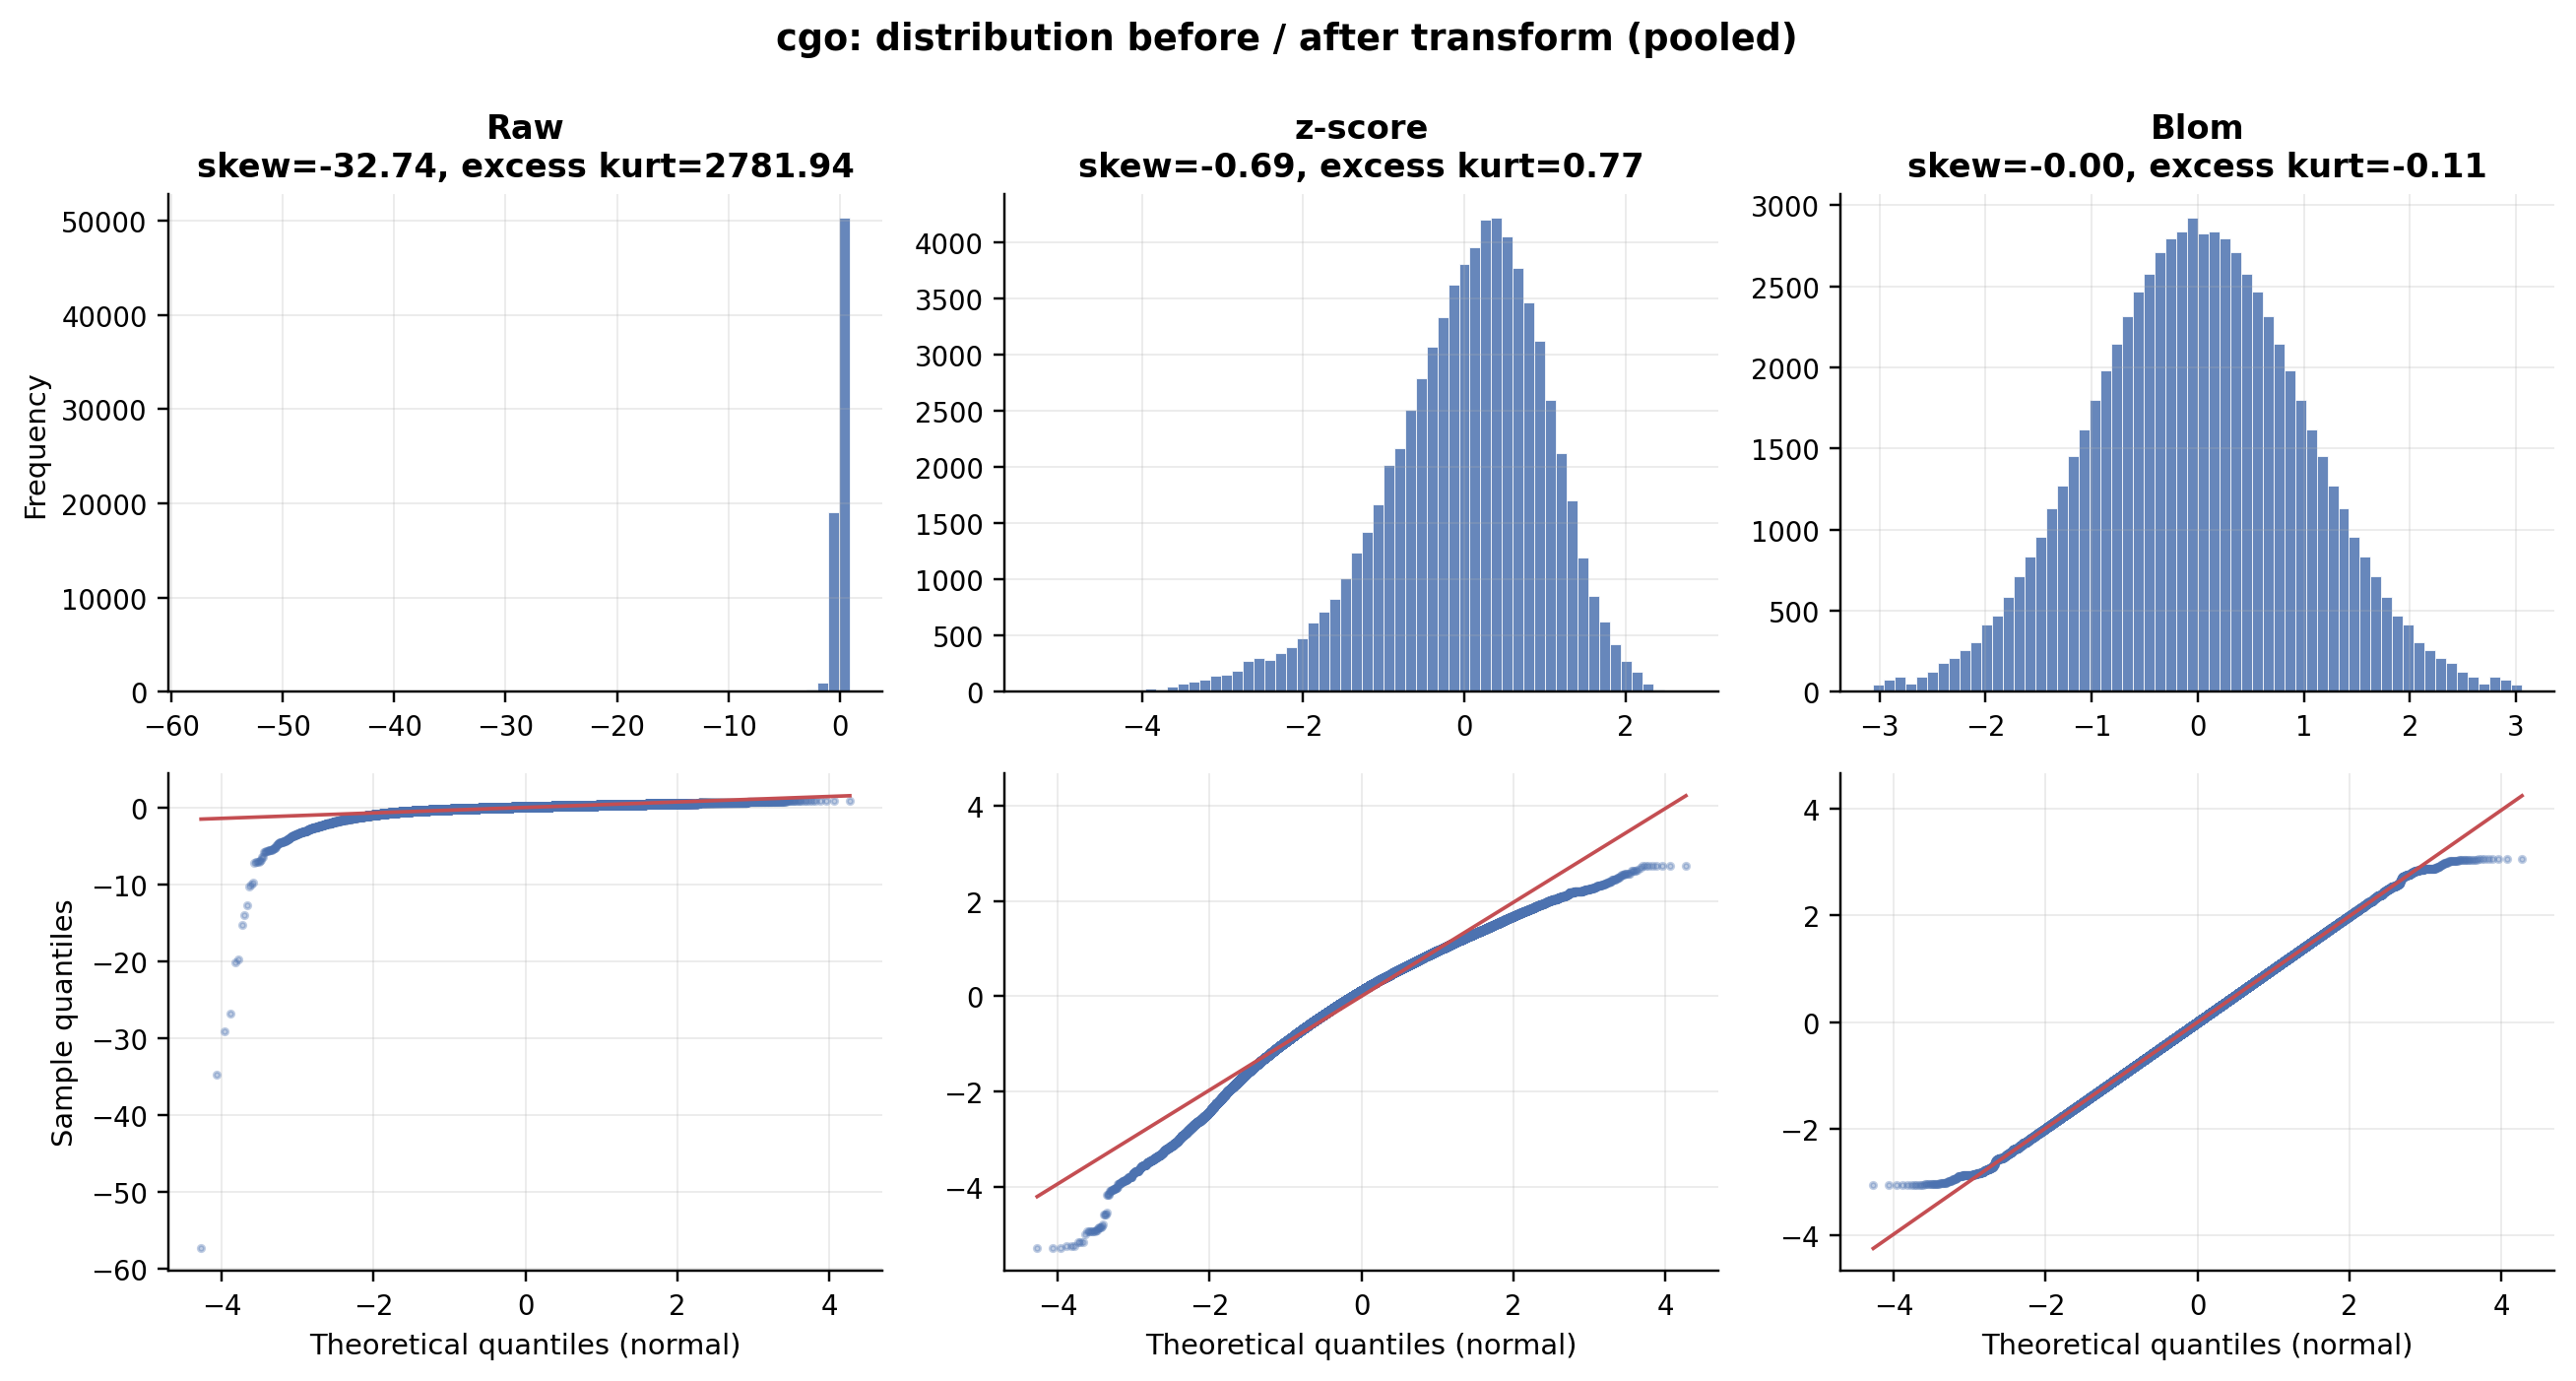

In [4]:
panel = fl.preprocess.standardize_panel(panel, "cgo", method="zscore", winsor=0.01)
panel = fl.preprocess.standardize_panel(panel, "cgo", method="blom")
fig = fl.plotting.plot_transform_comparison(panel, "cgo")
fl.plotting.savefig(fig, f"{FIGDIR}/60_cgo_transform");

## 3. スコアのバリアント

| バリアント | 定義 | 問い |
|---|---|---|
| raw | Blom | 素の CGO |
| size_sector | Blom → セクター+サイズ回帰残差 | 配分由来でないか |
| mom_neutral | Blom → **mom12_1 を追加でコントロール**した回帰残差 | CGO は結局モメンタムではないか |

CGO は定義上モメンタムと相関する（過去リターンが高い ↔ 含み益）。
モメンタムに対する**増分情報**があるかが検証の焦点。

In [5]:
panel = fl.preprocess.standardize_panel(panel, COMPARE, method="blom")
panel = fl.preprocess.standardize_panel(
    panel, "cgo", method="blom", group_col="sector", control_cols=["log_cap"],
    suffix="_blom_ss")
panel = fl.preprocess.standardize_panel(
    panel, "cgo", method="blom", group_col="sector",
    control_cols=["log_cap", "mom12_1_blom"], suffix="_blom_mn")

score_cols = {"raw": "cgo_blom", "size_sector": "cgo_blom_ss", "mom_neutral": "cgo_blom_mn"}
LABELS = {"raw": "Raw (Blom)", "size_sector": "Size + sector neutral",
          "mom_neutral": "Size + sector + momentum neutral"}

# モメンタム族との順位相関
cols = ["cgo_blom", "cgo_blom_ss", "cgo_blom_mn"] + [f"{c}_blom" for c in COMPARE]
labs = ["cgo", "cgo_ss", "cgo_mom_neutral"] + COMPARE
fl.multi.cross_sectional_corr(panel, cols, labels=labs).loc[
    ["cgo", "cgo_ss", "cgo_mom_neutral"], COMPARE]

,mom1,mom12,mom12_1,rev3p
cgo,0.307,0.702,0.648,0.403
cgo_ss,0.276,0.621,0.571,0.355
cgo_mom_neutral,0.347,0.130,0.035,0.133


## 4. 分位分析（Q5 = 高 CGO = 含み益大）

In [6]:
res, summaries = {}, {}
for v, col in score_cols.items():
    res[v] = fl.quantile.quantile_returns(panel, col, q=Q, ascending=True)
    summaries[v] = fl.quantile.quantile_summary(res[v], weighting=WEIGHTING)

spread = f"Q{Q}-Q1"
pd.concat({LABELS[v]: summaries[v].loc[[f"Q{Q}", spread, "NA"],
    ["ann_excess", "ann_excess_arith", "te", "IR", "t_stat_NW", "max_dd_excess",
     "turnover_ann", "n_stocks_mean"]] for v in score_cols}, names=["variant", "bucket"])

ann_excess  ann_excess_arith    te     IR  t_stat_NW  max_dd_excess  turnover_ann  n_stocks_mean
variant                          bucket                                                                                                  
Raw (Blom)                       Q5           0.080             0.068 0.108  0.627      3.035         -0.196         2.303         63.297
                                 Q5-Q1        0.081             0.104 0.221  0.470      2.111         -0.578         5.146            NaN
                                 NA          -0.081            -0.060 0.124 -0.482     -2.153         -0.733         0.998         57.626
Size + sector neutral            Q5           0.082             0.074 0.109  0.678      3.088         -0.250         2.328         63.297
                                 Q5-Q1        0.083             0.097 0.184  0.531      2.355         -0.472         5.285            NaN
                                 NA          -0.081            -0.060 0.124 -0.482     -2.153         -0.733         0.998         57.626
Size + sector + momentum neutral Q5           0.031             0.032 0.102  0.318      1.343         -0.255         3.852         63.234
                                 Q5-Q1        0.032             0.041 0.131  0.309      1.312         -0.310         8.490            NaN
                                 NA          -0.079            -0.058 0.124 -0.470     -2.087         -0.724         1.013         57.869

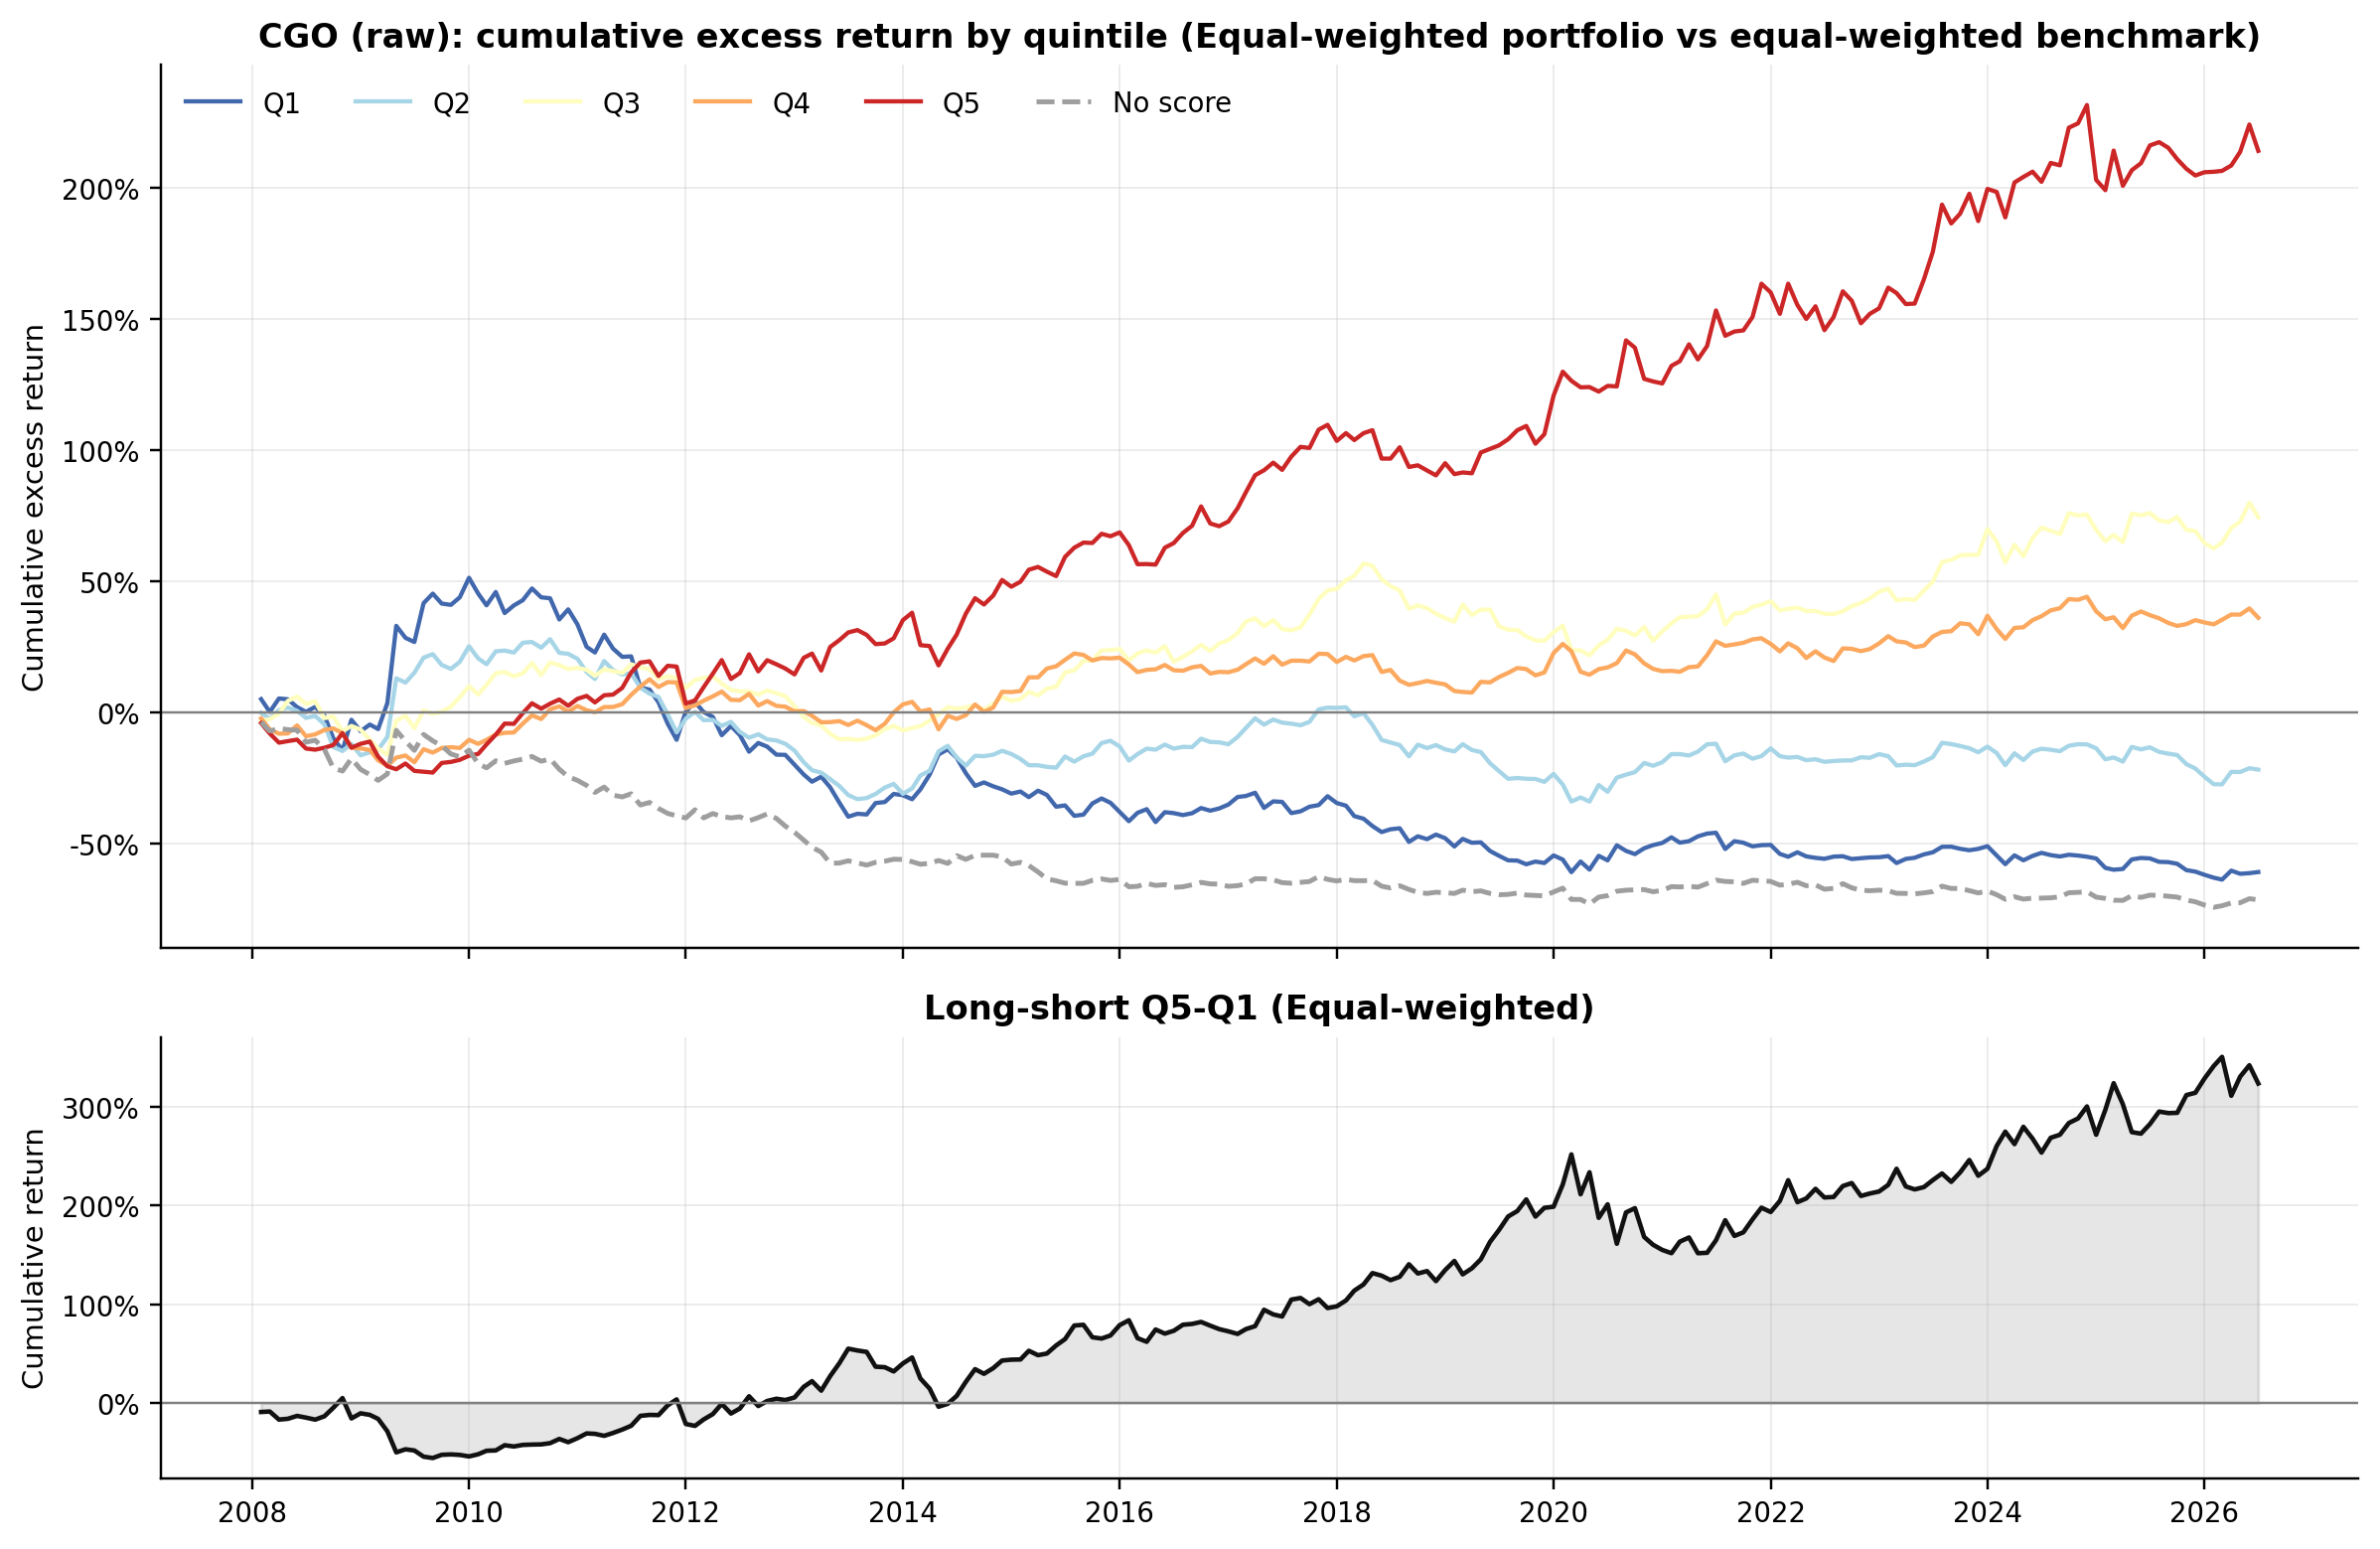

In [7]:
fig = fl.plotting.plot_quantile_timeseries(res["raw"], weighting=WEIGHTING, q=Q,
                                           factor="CGO (raw)", show_na=True)
fl.plotting.savefig(fig, f"{FIGDIR}/61_cgo_quantile_ts_raw");

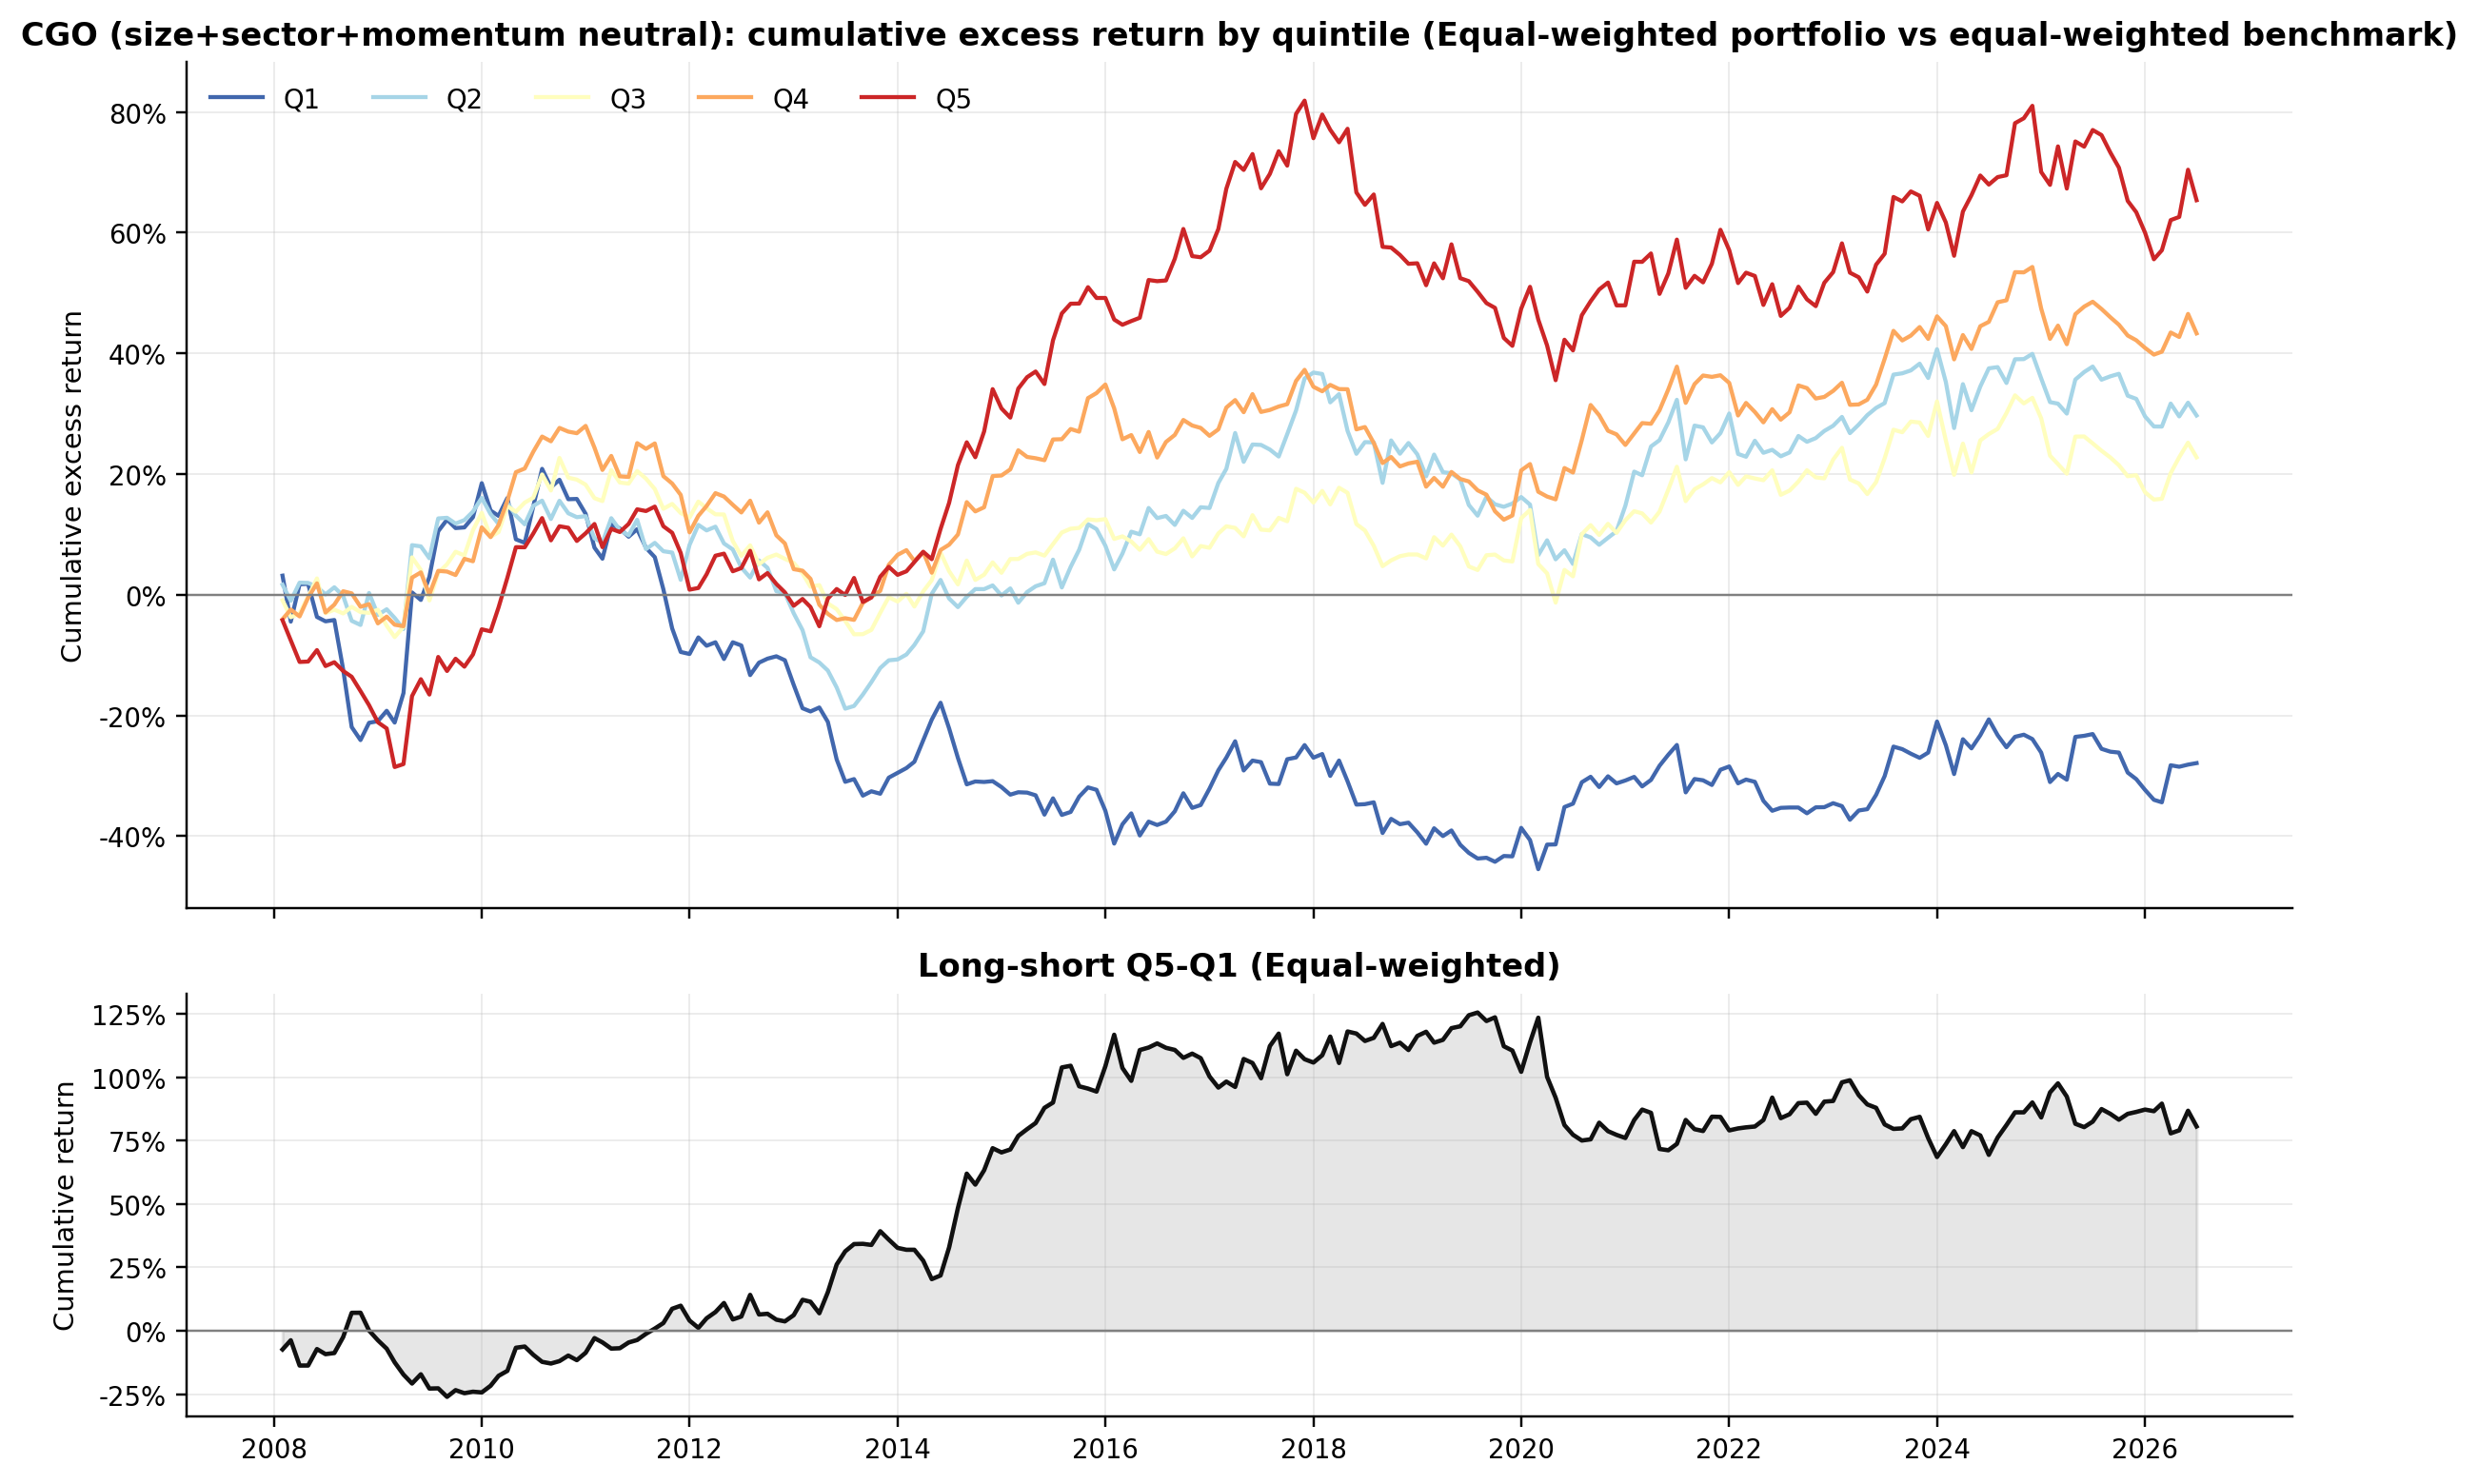

In [8]:
fig = fl.plotting.plot_quantile_timeseries(res["mom_neutral"], weighting=WEIGHTING, q=Q,
                                           factor="CGO (size+sector+momentum neutral)")
fl.plotting.savefig(fig, f"{FIGDIR}/62_cgo_quantile_ts_mom_neutral");

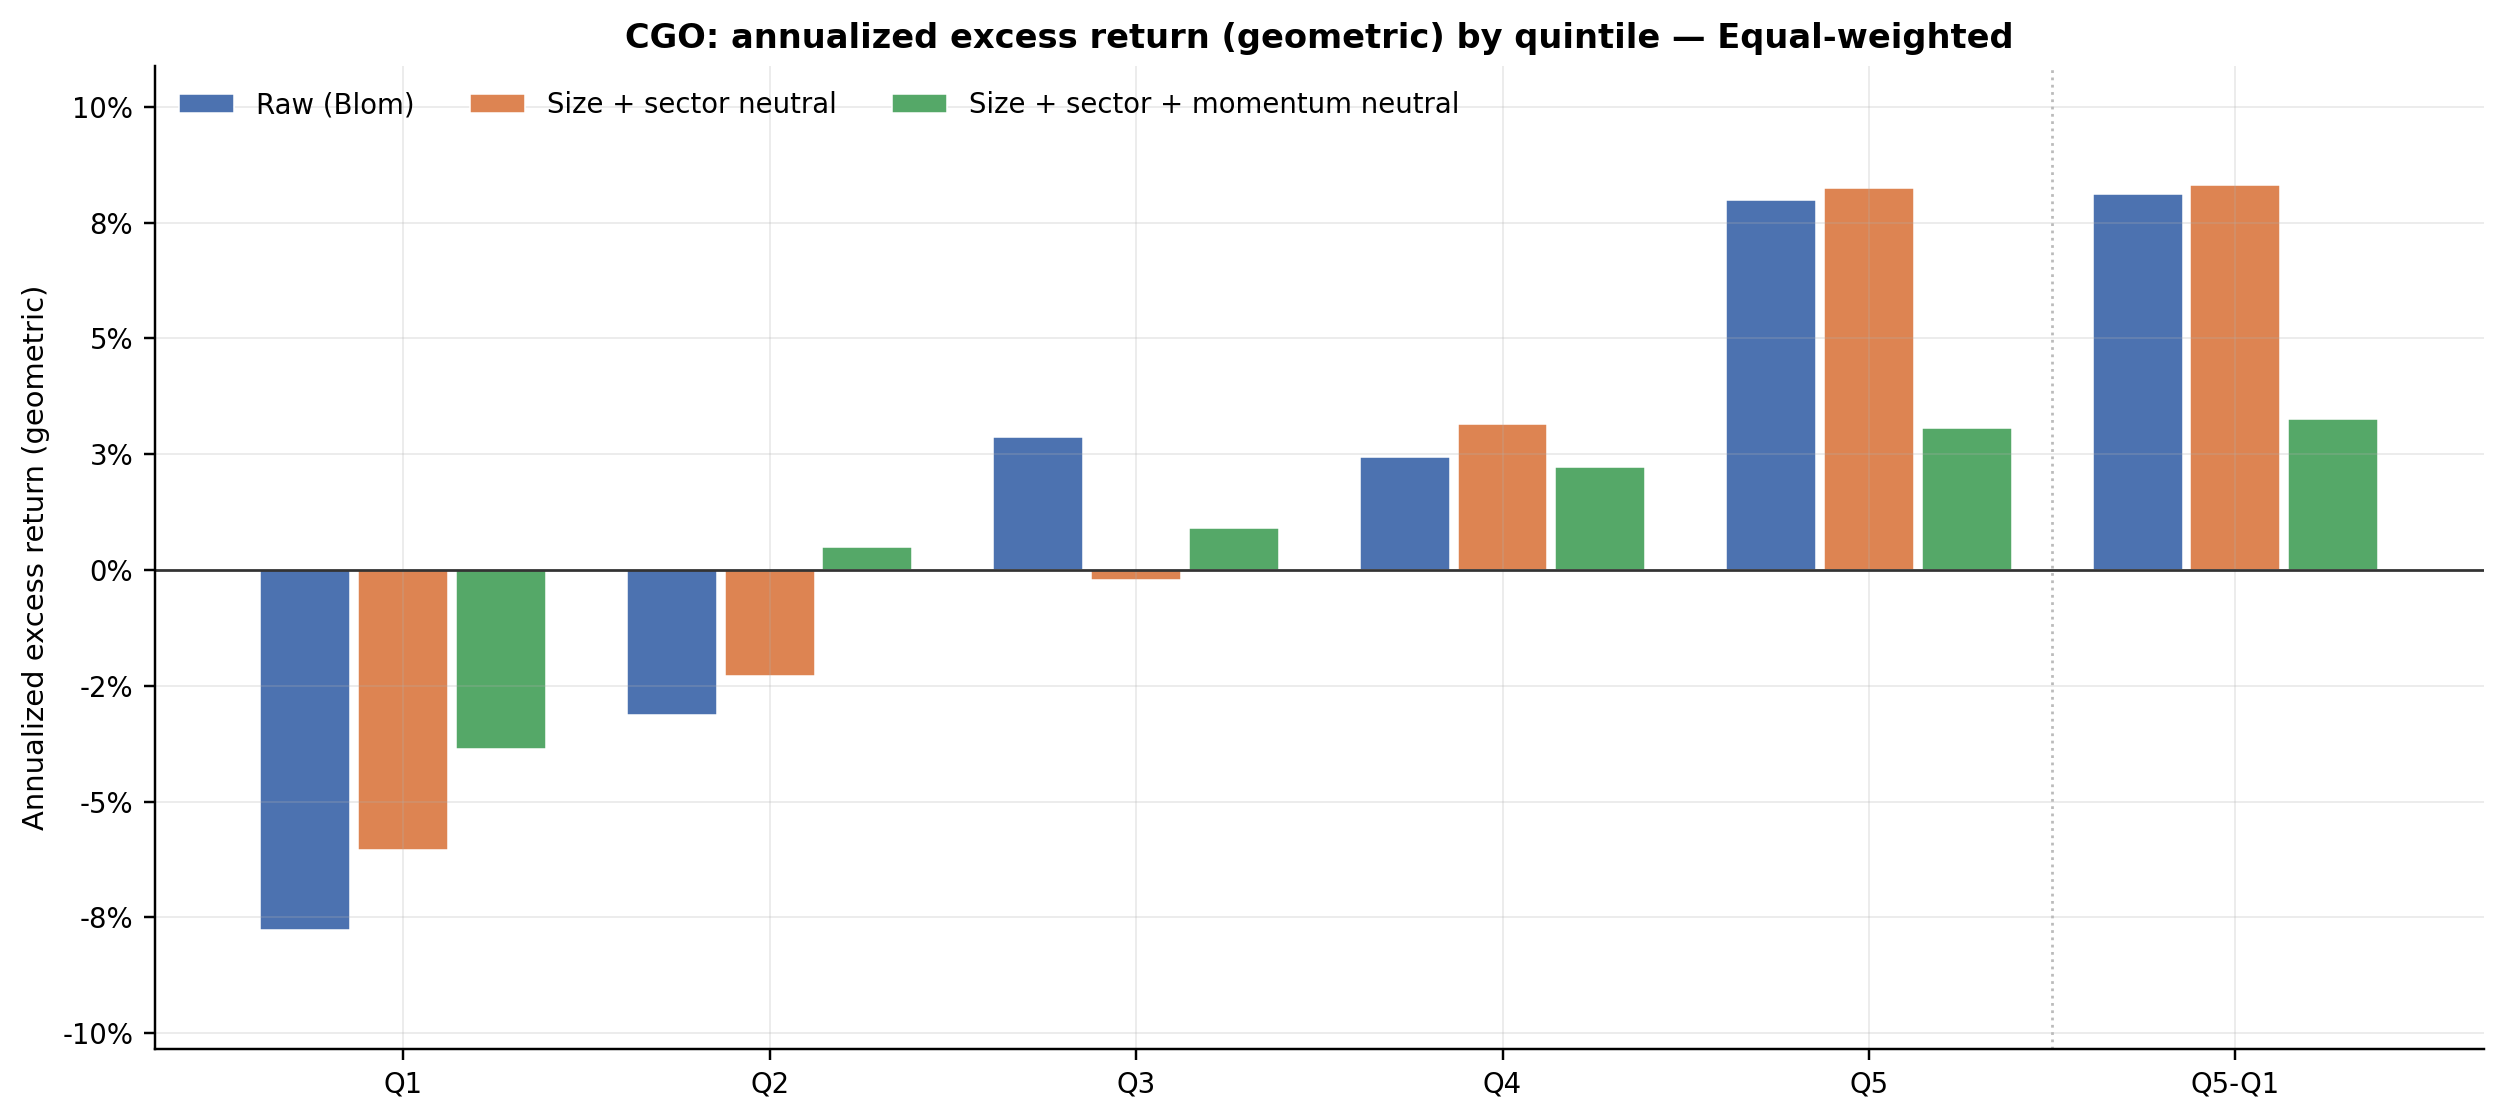

In [9]:
fig = fl.plotting.plot_variant_quantile_bar(summaries, q=Q, factor="CGO",
                                            weighting=WEIGHTING, labels=LABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/63_cgo_quantile_bar_variants");

## 5. IC

In [10]:
panel = fl.data.add_forward_returns(panel, range(1, 13))
ics, decays = {}, {}
for v, col in score_cols.items():
    ics[v] = fl.ic.information_coefficient(panel, col, "fwd_rtn", method="spearman")
    _, decays[v] = fl.ic.ic_decay(panel, col, horizons=range(1, 13), method="spearman")

pd.DataFrame({LABELS[v]: fl.ic.ic_summary(ics[v]) for v in score_cols}).T

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
Raw (Blom),222.000,0.054,0.204,0.265,0.917,3.945,4.211,0.631,0.003
Size + sector neutral,222.000,0.044,0.167,0.263,0.911,3.918,4.171,0.604,0.026
Size + sector + momentum neutral,222.000,0.022,0.129,0.173,0.598,2.571,2.819,0.563,0.023


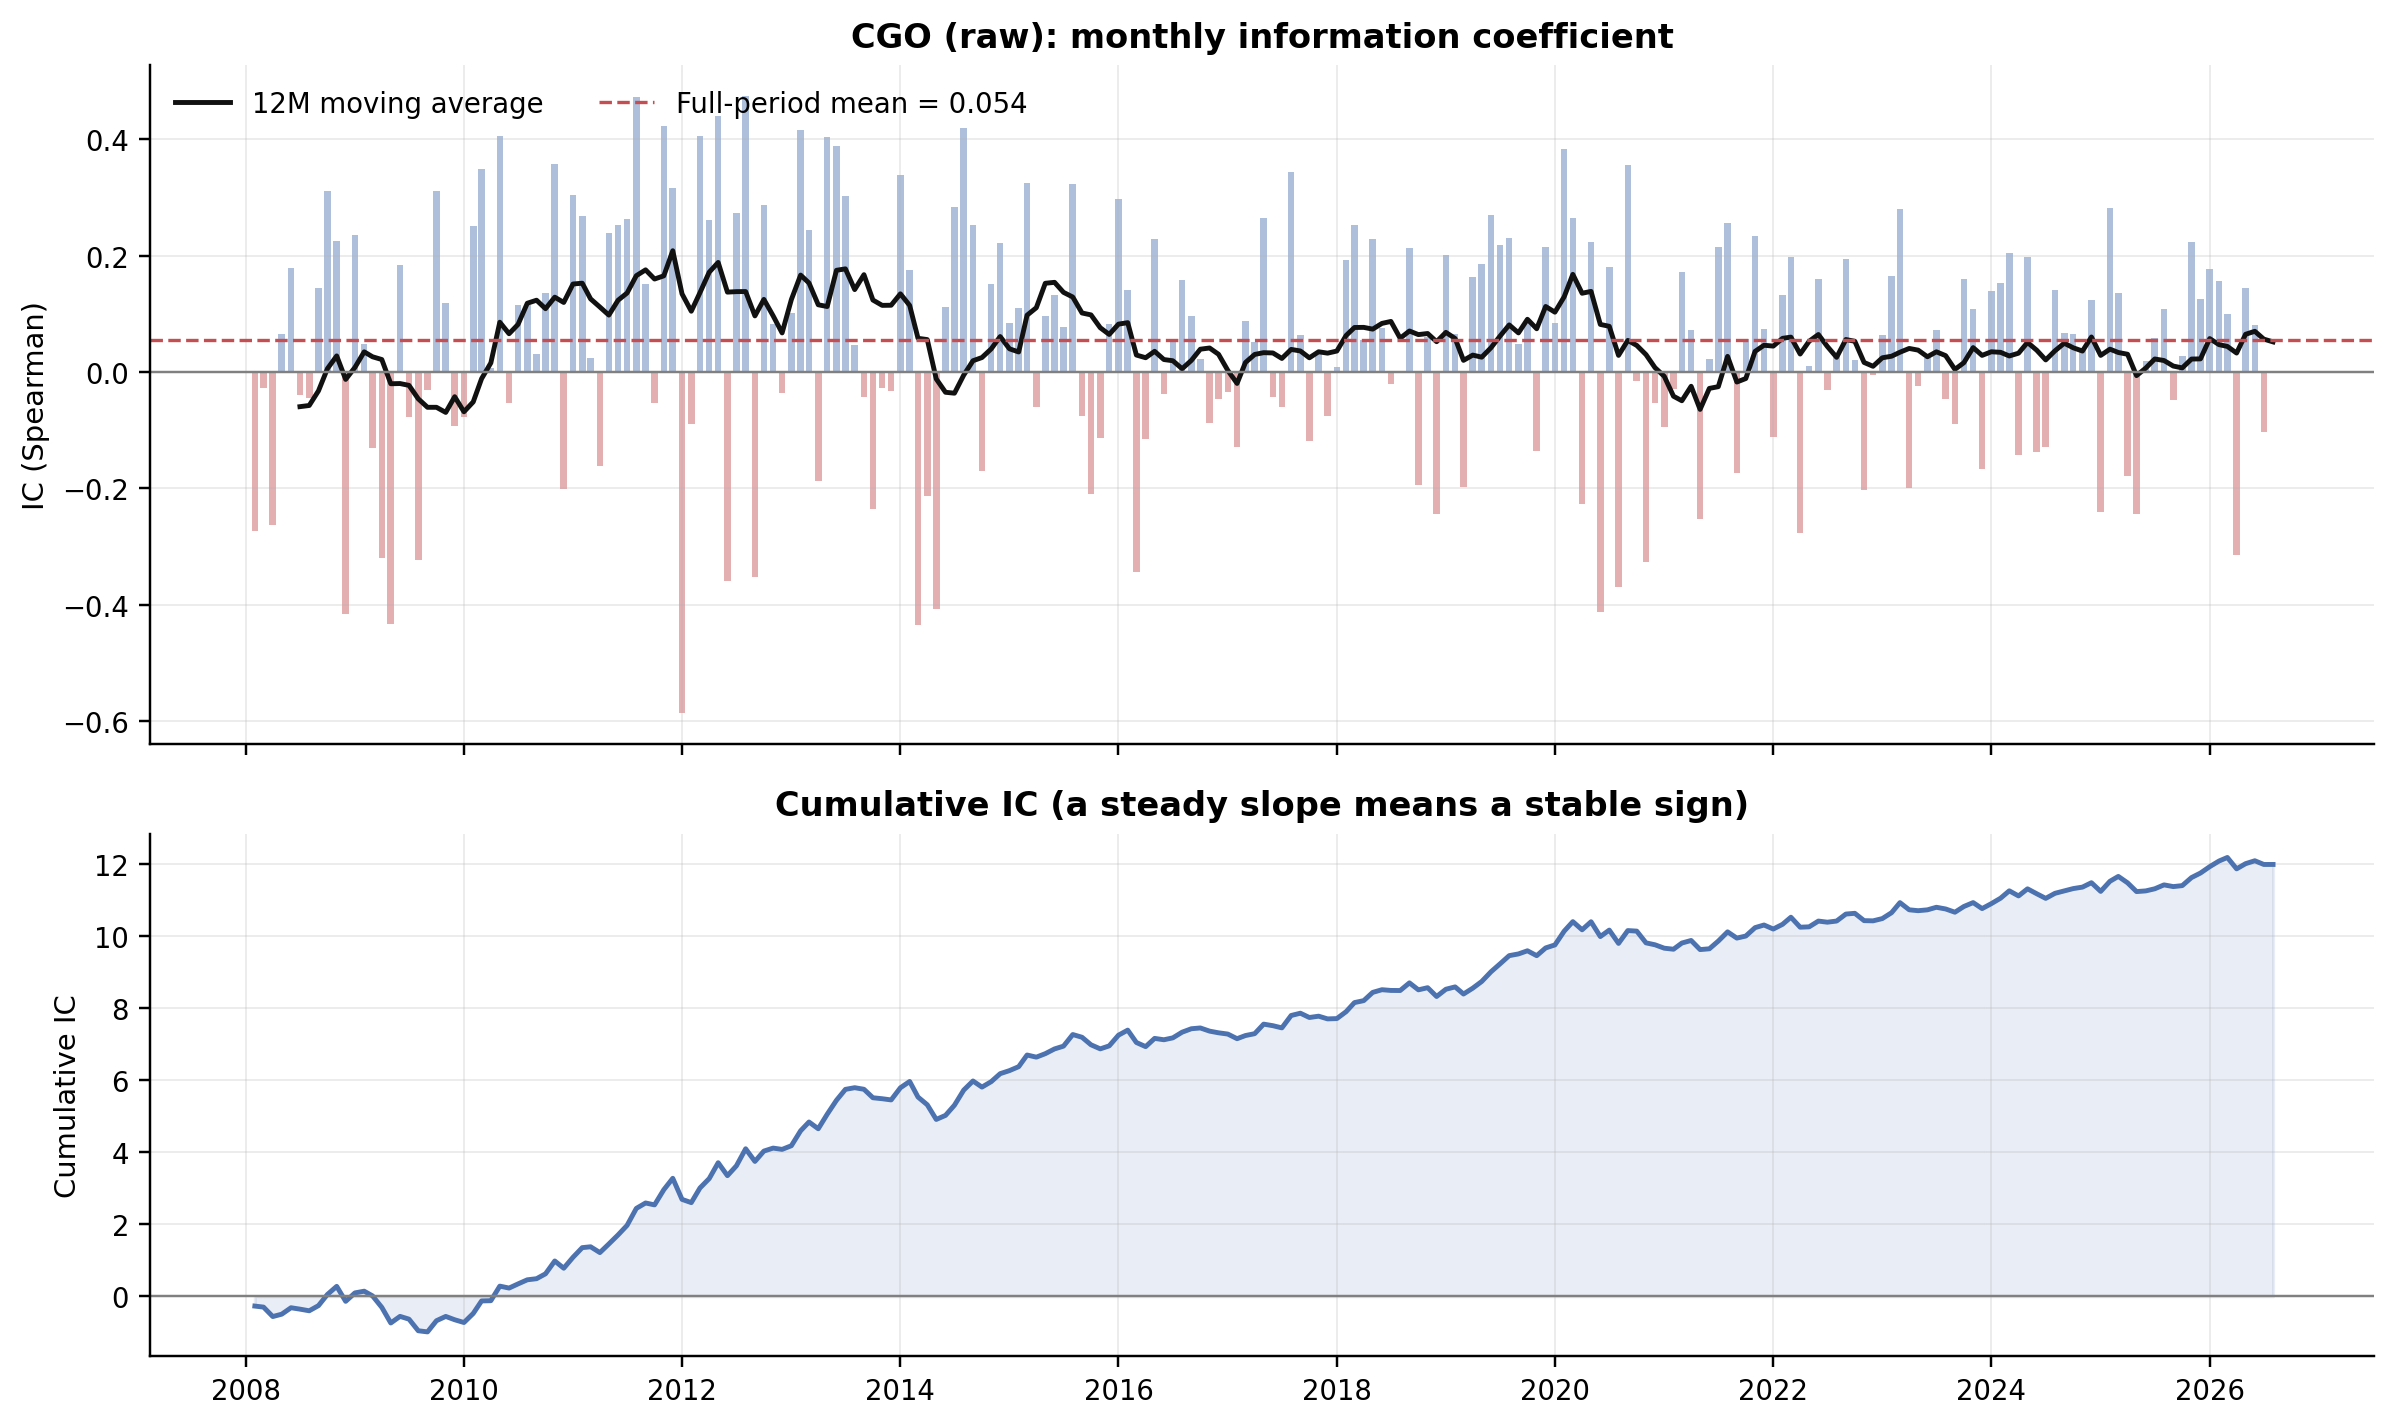

In [11]:
fig = fl.plotting.plot_ic(ics["raw"], ma_window=12, factor="CGO (raw)", method="Spearman")
fl.plotting.savefig(fig, f"{FIGDIR}/64_cgo_ic_raw");

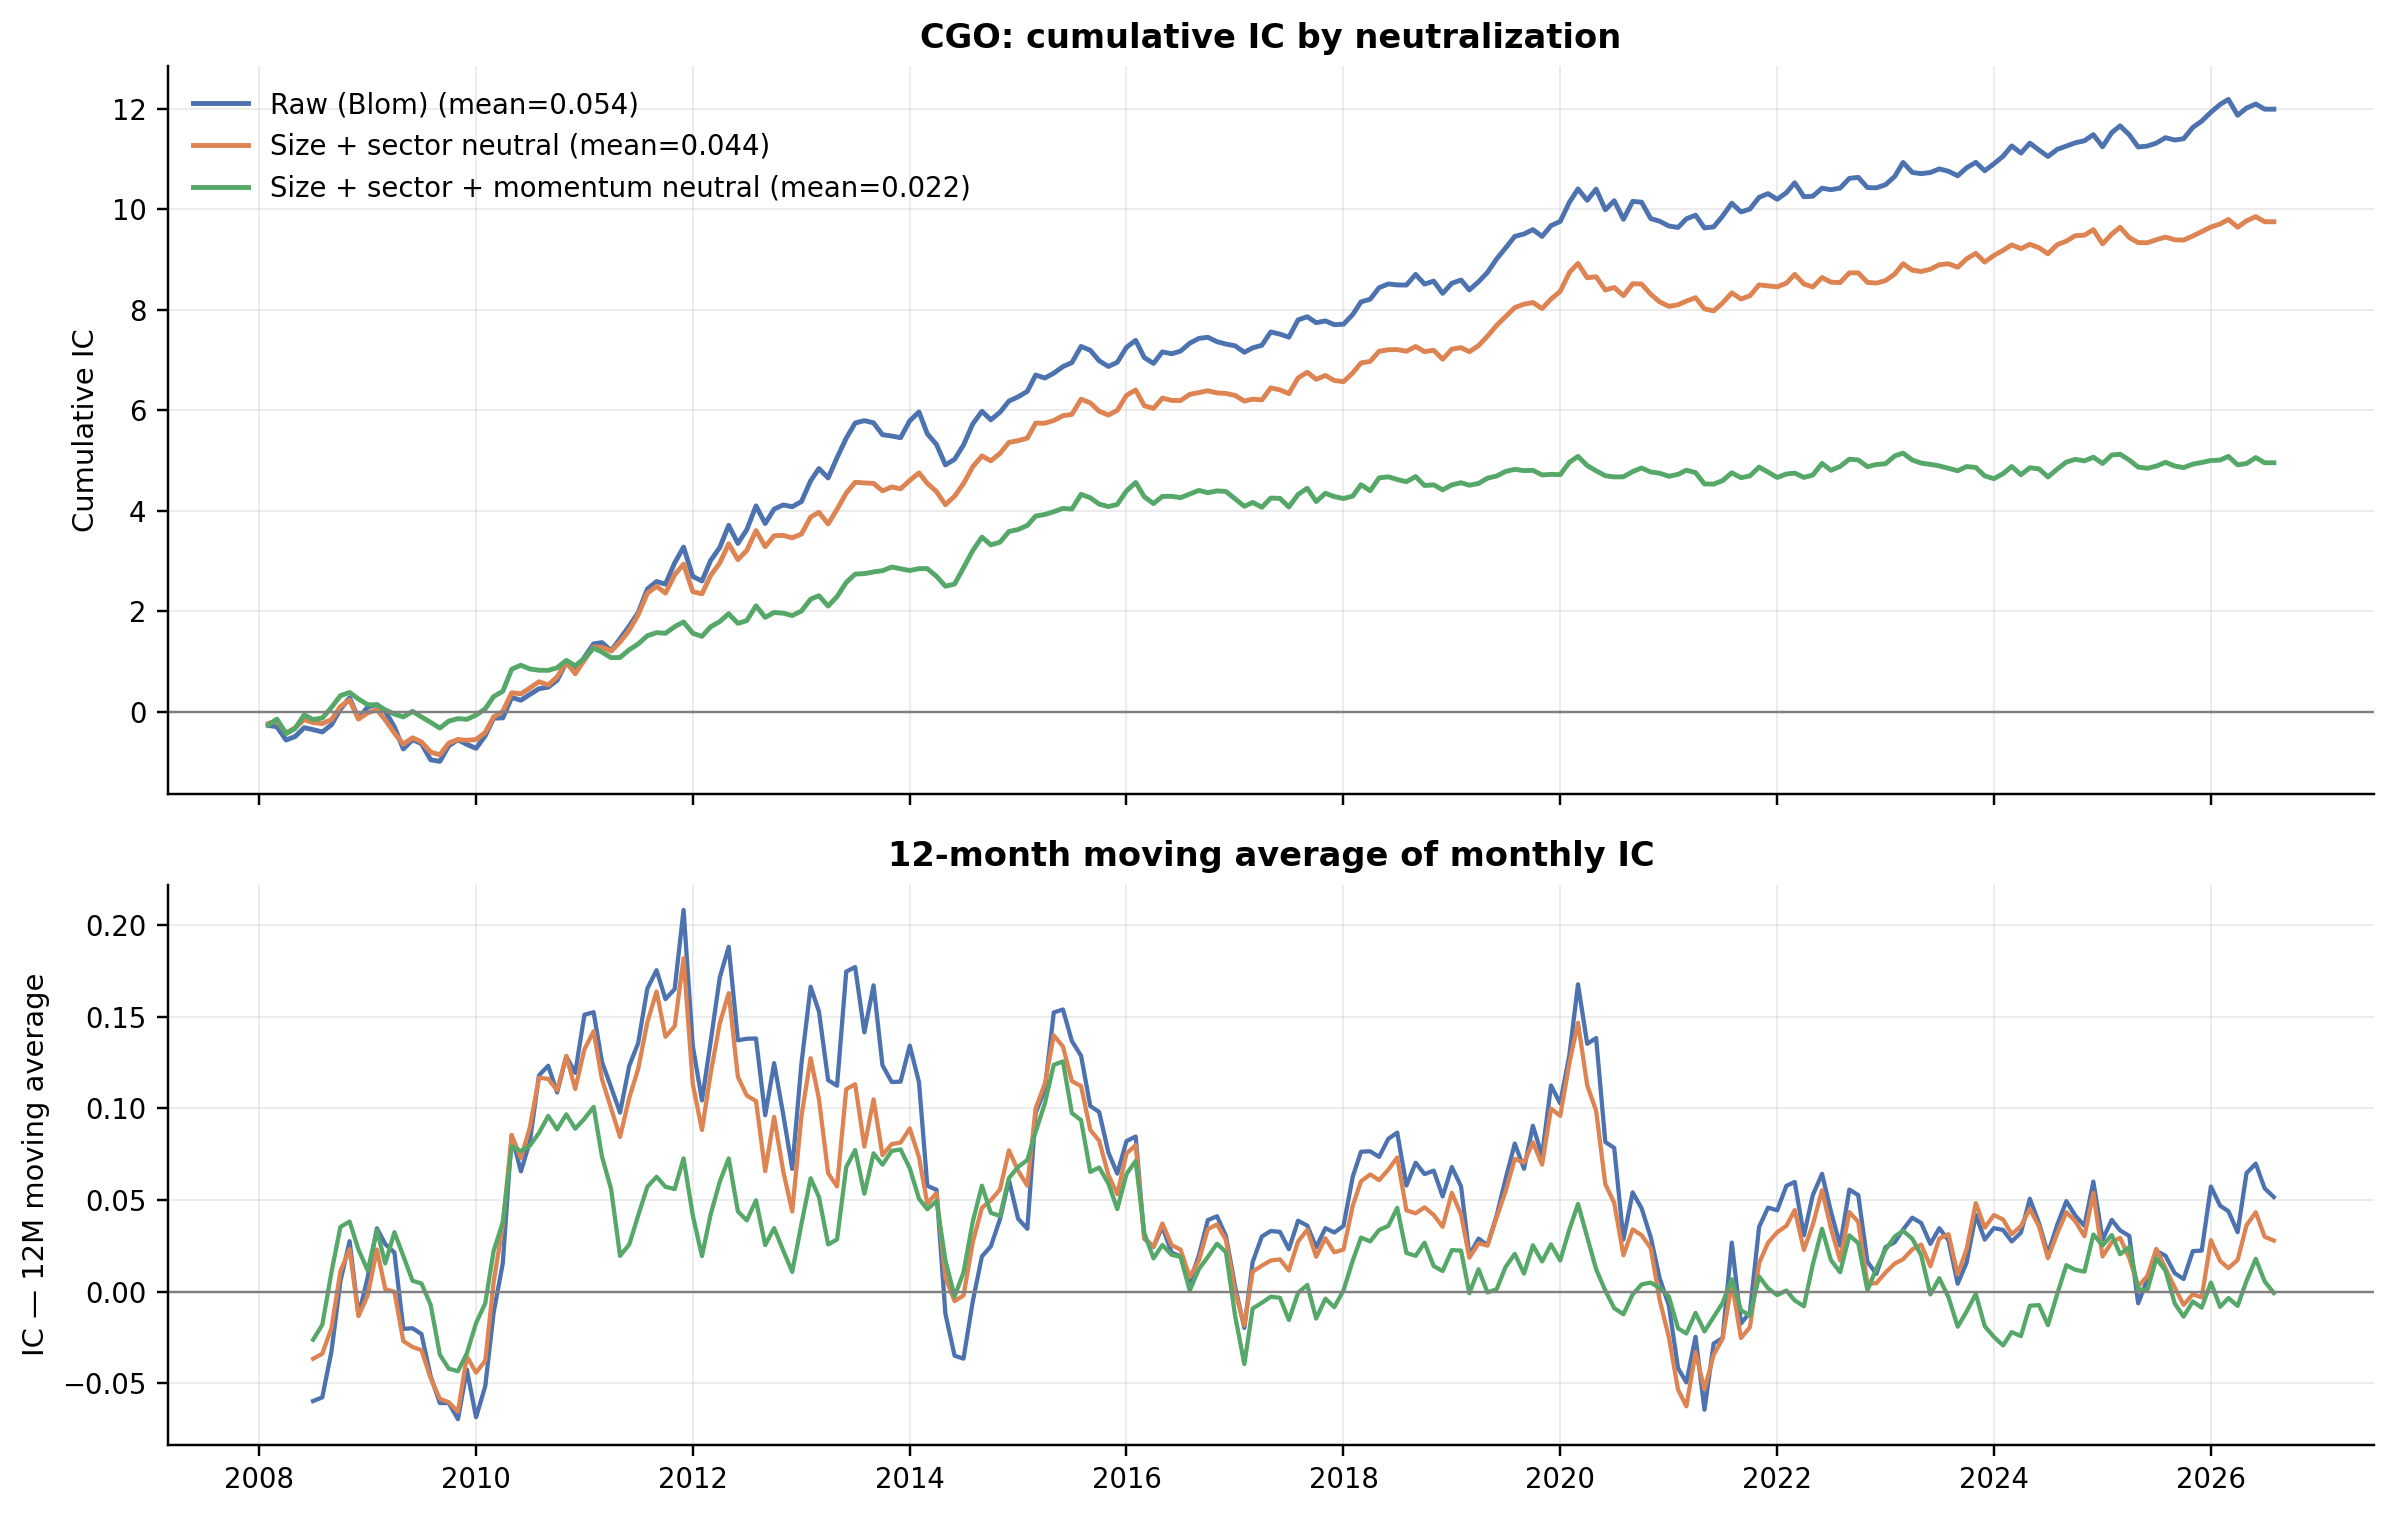

In [12]:
fig = fl.plotting.plot_cumulative_ic_compare(ics, factor="CGO", labels=LABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/65_cgo_cumulative_ic");

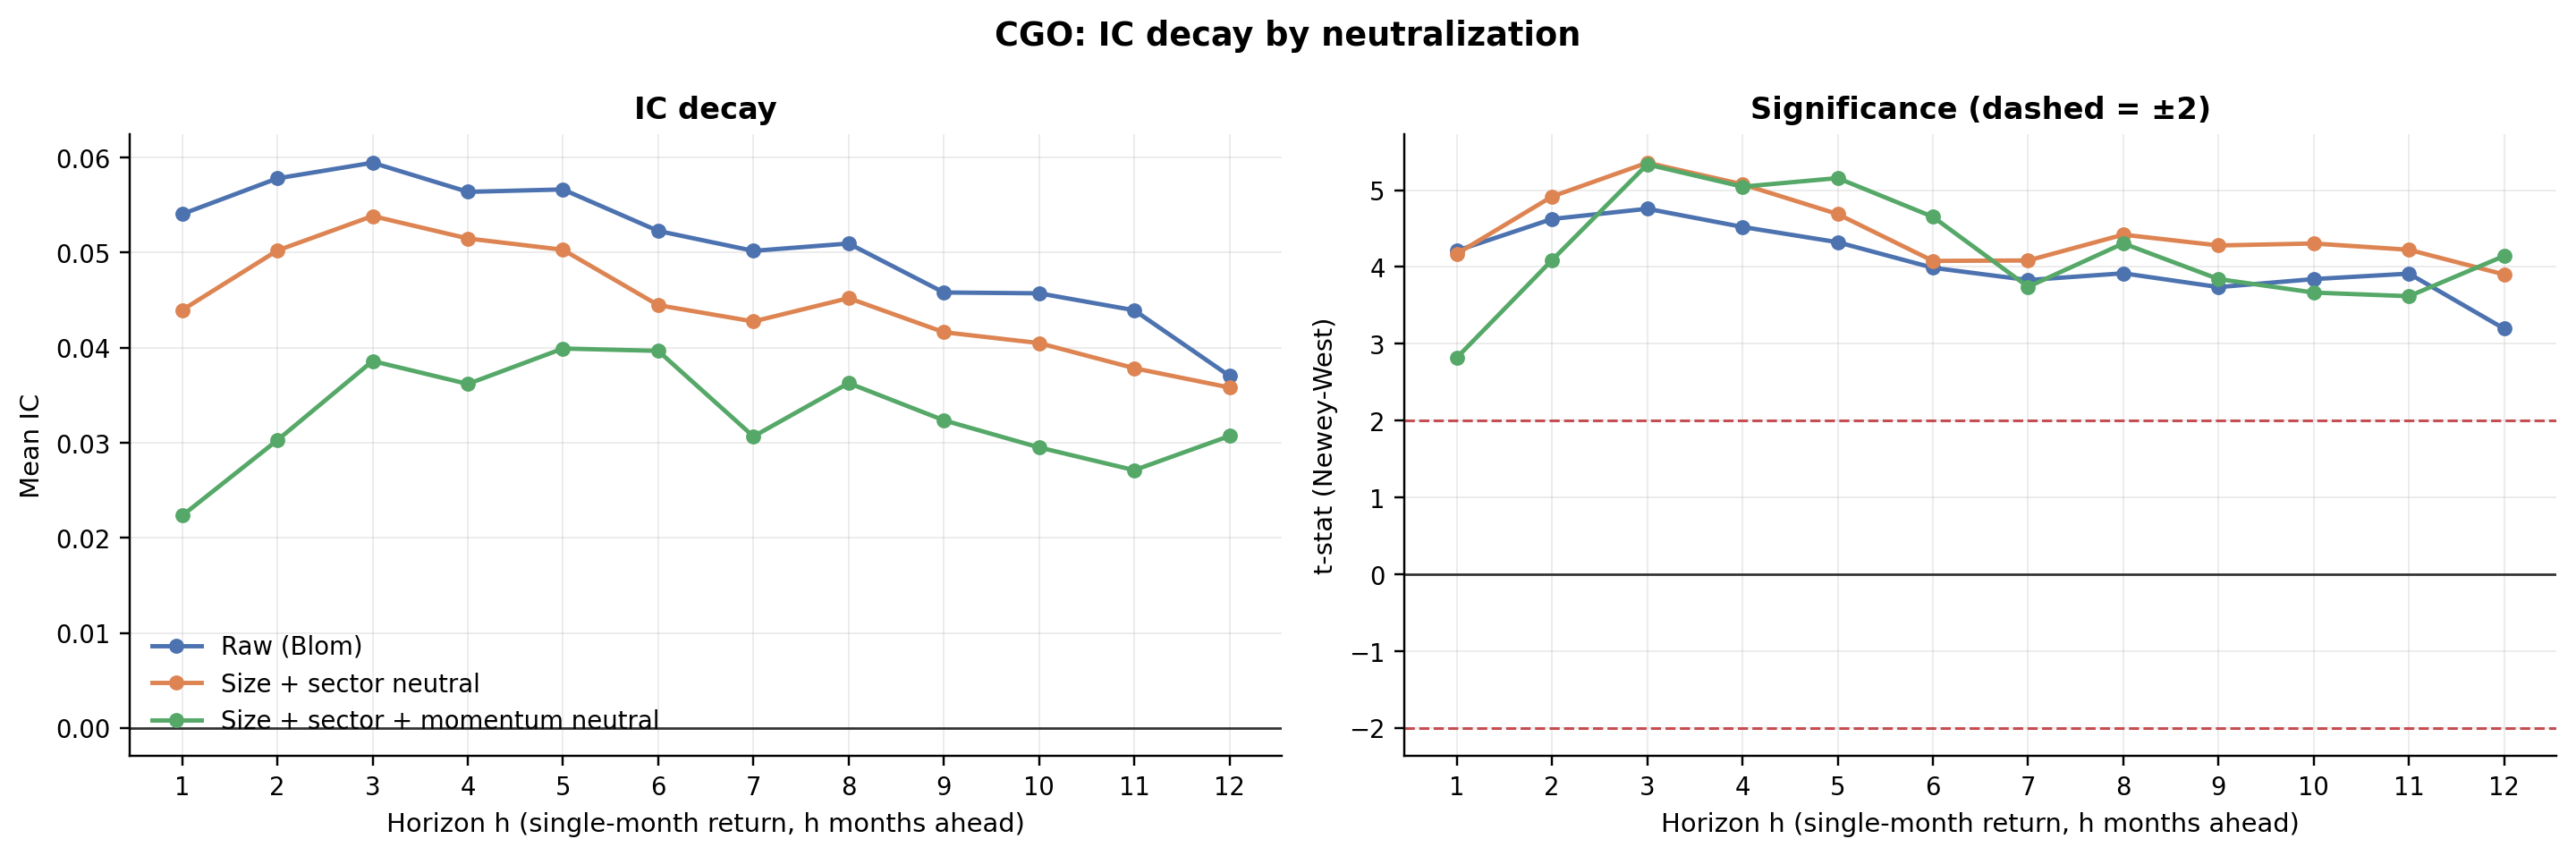

In [13]:
fig = fl.plotting.plot_ic_decay_compare(decays, factor="CGO", labels=LABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/66_cgo_ic_decay");

## 6. mom12_1 との直接対決（同じ期間・同じ規約）

In [14]:
sb, _ = fl.multi.factor_scoreboard(
    panel,
    {"cgo": "cgo_blom", "cgo_mom_neutral": "cgo_blom_mn",
     "mom12_1": "mom12_1_blom", "rev3p": "rev3p_blom"},
    q=Q, weighting=WEIGHTING)
sb[["ls_ann_excess", "ls_IR", "ls_t_NW", "top_ann_excess", "top_IR", "top_t_NW",
    "mean_IC", "ICIR_ann", "IC_t_NW", "ls_turnover_ann", "coverage"]]

,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,IC_t_NW,ls_turnover_ann,coverage
cgo,0.081,0.470,2.111,0.080,0.627,3.035,0.054,0.917,4.211,5.146,0.846
cgo_mom_neutral,0.032,0.309,1.312,0.031,0.318,1.343,0.022,0.598,2.819,8.490,0.845
mom12_1,0.062,0.395,1.634,0.038,0.334,1.450,0.051,0.956,4.160,6.456,0.998
rev3p,0.145,0.963,4.299,0.106,1.016,4.265,0.055,1.435,6.287,7.797,0.888


---

## 読みどころ

1. **raw CGO の有効性**（分位・IC）と、その何割がモメンタムで説明されるか
   （mom_neutral バリアントとの差）
2. CGO と mom12/mom12_1 の順位相関の高さ（定義上の重なり）
3. NA バケット: turnover データがない銘柄（履歴 104 週未満の新規上場等）のパフォーマンス